<a href="https://colab.research.google.com/github/ayeshanoorqureshi111-coder/Malaria-Detection/blob/main/Malaria_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MALARIA DETECTION USING MACHINE LEARNING

Checking hardware...
GPU not available.
The project will run on CPU.


DOWNLOADING MALARIA DATASET

353452851/353452851 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

ZIP file found:
/content/cell_images.zip

Extracting dataset...
Dataset extracted successfully ✅

Searching for image folders...

Dataset folders found successfully ✅
Parasitized folder: /content/malaria_dataset/cell_images/Parasitized
Uninfected folder: /content/malaria_dataset/cell_images/Uninfected

Preparing dataset...
Parasitized images: 13779
Uninfected images: 13779

Dataset preparation completed ✅

Loading images...
Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.

Classes:
['Parasitized', 'Uninfected']

Displaying sample images...


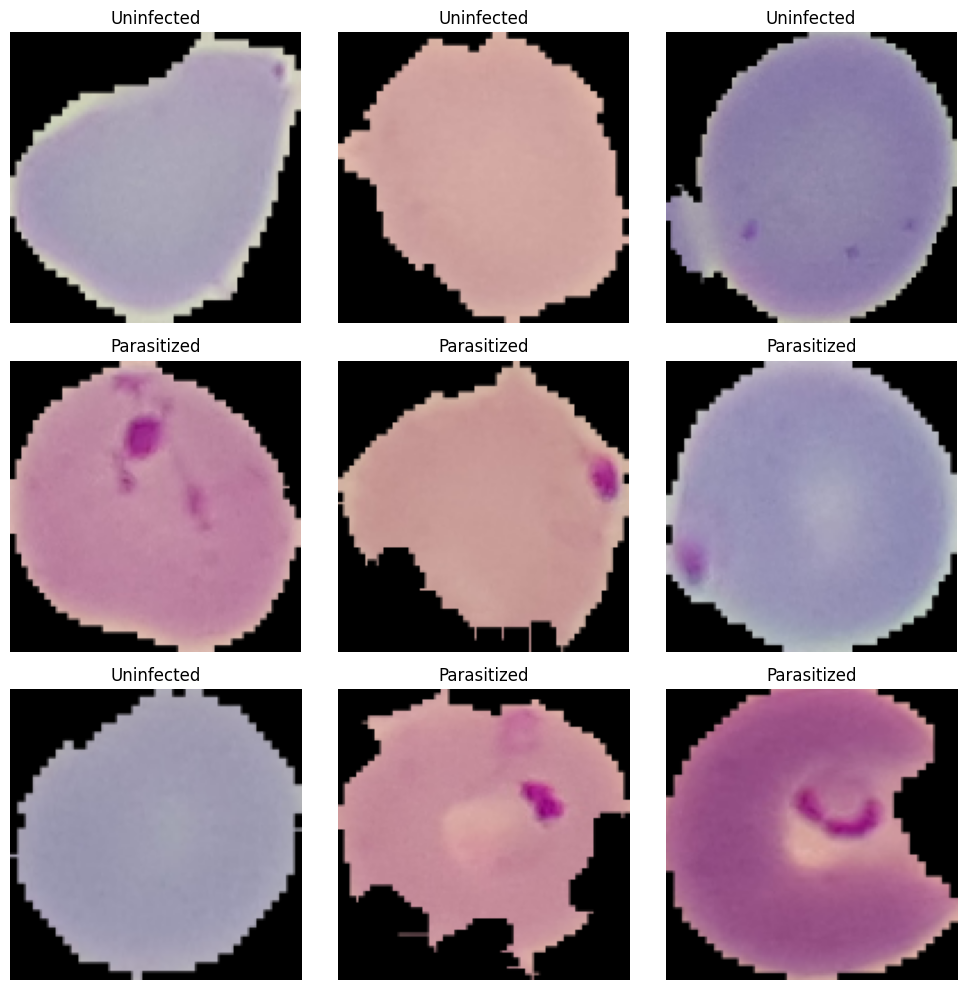



BUILDING MACHINE LEARNING MODEL
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model created successfully ✅


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)



TRAINING MODEL

Training for 5 epochs...
Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 390s 556ms/step - accuracy: 0.8802 - loss: 0.2939 - val_accuracy: 0.9202 - val_loss: 0.1973
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 370s 537ms/step - accuracy: 0.9084 - loss: 0.2352 - val_accuracy: 0.9211 - val_loss: 0.1983
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 391s 550ms/step - accuracy: 0.9141 - loss: 0.2219 - val_accuracy: 0.9361 - val_loss: 0.1714
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 382s 554ms/step - accuracy: 0.9166 - loss: 0.2145 - val_accuracy: 0.9363 - val_loss: 0.1824
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 372s 540ms/step - accuracy: 0.9191 - loss: 0.2086 - val_accuracy: 0.9314 - val_loss: 0.1718


MODEL EVALUATION
173/173 ━━━━━━━━━━━━━━━━━━━━ 79s 458ms/step - accuracy: 0.9314 - loss: 0.1718

Validation Loss: 0.1718
Validation Accuracy: 93.14%


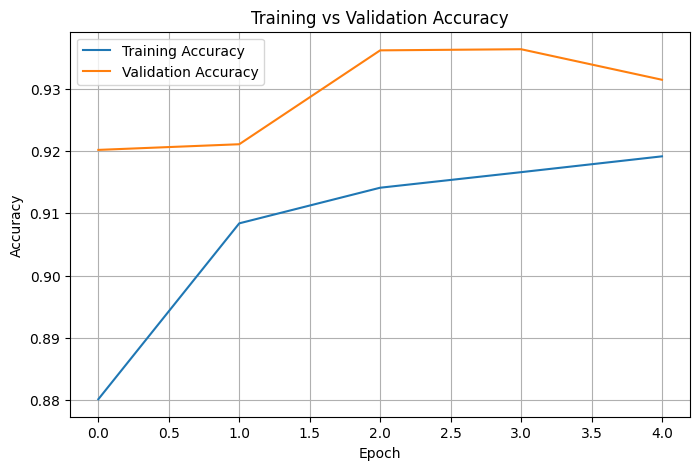

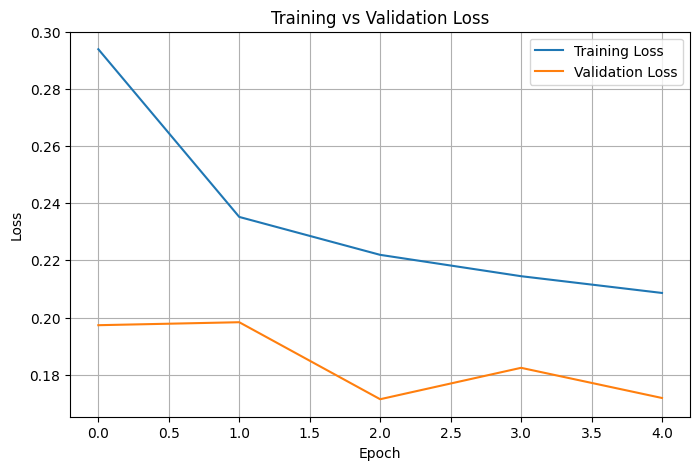



SAMPLE PREDICTIONS


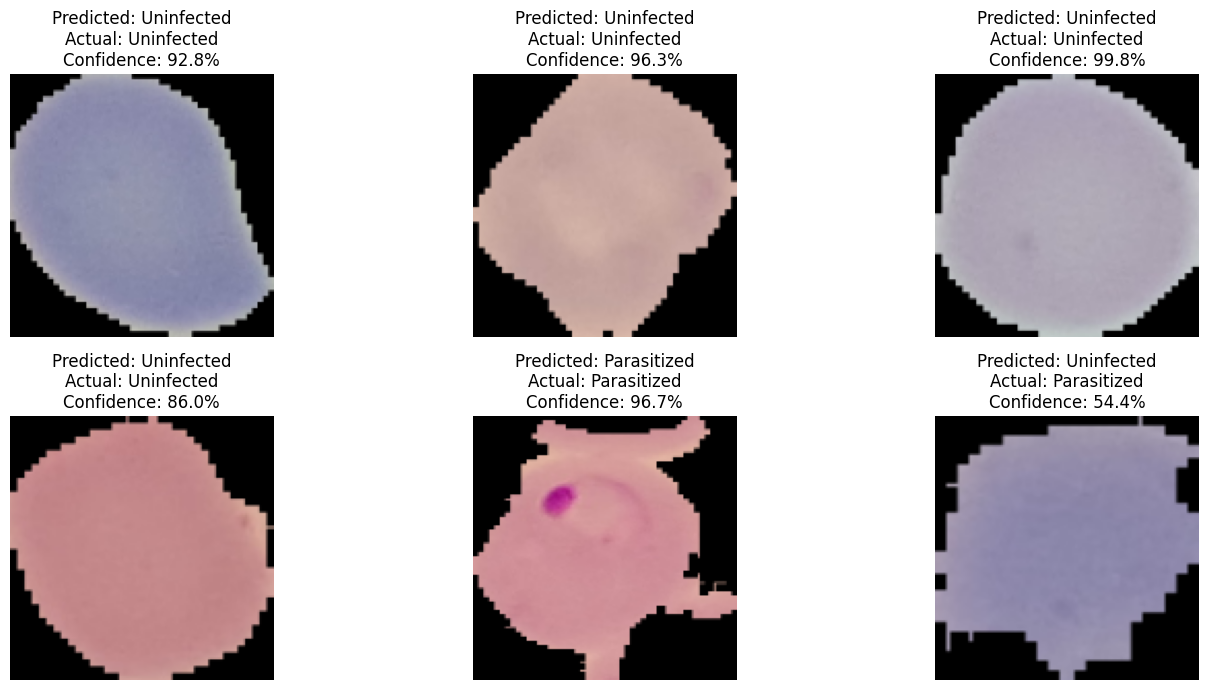



TEST YOUR OWN BLOOD CELL IMAGE

Upload a microscopic blood-cell image.


In [ ]:
# ============================================================
# PROJECT 3: MALARIA DETECTION USING MACHINE LEARNING
# Google Colab - Complete Fixed Version
# ============================================================

# ============================================================
# 1. INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install tensorflow opencv-python matplotlib seaborn


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import zipfile
import pathlib
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image

from google.colab import files


print("=" * 70)
print("MALARIA DETECTION USING MACHINE LEARNING")
print("=" * 70)


# ============================================================
# 3. CHECK GPU
# ============================================================

print("\nChecking hardware...")

if tf.config.list_physical_devices("GPU"):

    print("GPU available ✅")

    for gpu in tf.config.list_physical_devices("GPU"):
        print(gpu)

else:

    print("GPU not available.")
    print("The project will run on CPU.")


# ============================================================
# 4. DOWNLOAD DATASET
# ============================================================

print("\n")
print("=" * 70)
print("DOWNLOADING MALARIA DATASET")
print("=" * 70)

dataset_url = (
    "https://data.lhncbc.nlm.nih.gov/"
    "public/Malaria/cell_images.zip"
)

zip_path = "/content/cell_images.zip"

# Download only if it doesn't already exist
if not os.path.exists(zip_path):

    print("\nDownloading dataset...")

    tf.keras.utils.get_file(
        fname="cell_images.zip",
        origin=dataset_url,
        cache_dir="/content",
        cache_subdir=""
    )

    # The downloaded file should now exist as /content/cell_images.zip

else:

    print("Dataset ZIP already exists.")


# ============================================================
# 5. VERIFY ZIP FILE
# ============================================================

if not os.path.exists(zip_path):

    # Search for the downloaded ZIP file
    possible_files = []

    for root, dirs, files_list in os.walk("/content"):

        for filename in files_list:

            if filename.endswith(".zip"):

                possible_files.append(
                    os.path.join(root, filename)
                )

    if possible_files:

        zip_path = possible_files[0]

    else:

        raise FileNotFoundError(
            "Could not find the downloaded ZIP file."
        )


print("\nZIP file found:")
print(zip_path)


# ============================================================
# 6. EXTRACT DATASET
# ============================================================

extract_path = "/content/malaria_dataset"

print("\nExtracting dataset...")

if not os.path.exists(extract_path):

    os.makedirs(extract_path)

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            extract_path
        )

    print("Dataset extracted successfully ✅")

else:

    print("Dataset is already extracted.")


# ============================================================
# 7. FIND CORRECT DATASET DIRECTORY
# ============================================================

print("\nSearching for image folders...")

parasitized_dir = None
uninfected_dir = None


for root, dirs, files_list in os.walk(
    extract_path
):

    folder_names = [
        d.lower()
        for d in dirs
    ]

    if (
        "parasitized" in folder_names
        and
        "uninfected" in folder_names
    ):

        parasitized_name = [
            d for d in dirs
            if d.lower() == "parasitized"
        ][0]

        uninfected_name = [
            d for d in dirs
            if d.lower() == "uninfected"
        ][0]

        parasitized_dir = os.path.join(
            root,
            parasitized_name
        )

        uninfected_dir = os.path.join(
            root,
            uninfected_name
        )

        break


if parasitized_dir is None:

    raise FileNotFoundError(
        "Could not find Parasitized and Uninfected folders."
    )


print("\nDataset folders found successfully ✅")

print(
    "Parasitized folder:",
    parasitized_dir
)

print(
    "Uninfected folder:",
    uninfected_dir
)


# ============================================================
# 8. CREATE CLEAN DATASET DIRECTORY
# ============================================================

data_dir = "/content/malaria_data"

if os.path.exists(data_dir):

    shutil.rmtree(data_dir)


os.makedirs(data_dir)

os.makedirs(
    os.path.join(
        data_dir,
        "Parasitized"
    )
)

os.makedirs(
    os.path.join(
        data_dir,
        "Uninfected"
    )
)


# ============================================================
# 9. COPY IMAGES
# ============================================================

print("\nPreparing dataset...")

for source_dir, class_name in [
    (parasitized_dir, "Parasitized"),
    (uninfected_dir, "Uninfected")
]:

    destination_dir = os.path.join(
        data_dir,
        class_name
    )

    image_files = [
        f for f in os.listdir(source_dir)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ]

    print(
        class_name,
        "images:",
        len(image_files)
    )

    for filename in image_files:

        source_file = os.path.join(
            source_dir,
            filename
        )

        destination_file = os.path.join(
            destination_dir,
            filename
        )

        shutil.copy2(
            source_file,
            destination_file
        )


print("\nDataset preparation completed ✅")


# ============================================================
# 10. LOAD DATASET
# ============================================================

IMG_SIZE = (128, 128)

BATCH_SIZE = 32


print("\nLoading images...")


train_ds = tf.keras.utils.image_dataset_from_directory(

    data_dir,

    validation_split=0.20,

    subset="training",

    seed=42,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)


val_ds = tf.keras.utils.image_dataset_from_directory(

    data_dir,

    validation_split=0.20,

    subset="validation",

    seed=42,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)


class_names = train_ds.class_names


print("\nClasses:")
print(class_names)


# ============================================================
# 11. OPTIMIZE DATA PIPELINE
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)


val_ds = (
    val_ds
    .cache()
    .prefetch(AUTOTUNE)
)


# ============================================================
# 12. DISPLAY SAMPLE IMAGES
# ============================================================

print("\nDisplaying sample images...")


plt.figure(
    figsize=(10, 10)
)


for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(
            3,
            3,
            i + 1
        )

        plt.imshow(
            images[i].numpy().astype(
                "uint8"
            )
        )

        plt.title(
            class_names[
                labels[i]
            ]
        )

        plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# 13. BUILD MOBILE NET V2 MODEL
# ============================================================

print("\n")
print("=" * 70)
print("BUILDING MACHINE LEARNING MODEL")
print("=" * 70)


base_model = MobileNetV2(

    input_shape=(
        128,
        128,
        3
    ),

    include_top=False,

    weights="imagenet"

)


# Freeze pretrained layers

base_model.trainable = False


model = models.Sequential([

    layers.Rescaling(
        1.0 / 255
    ),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(
        0.3
    ),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(
        0.2
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )

])


# ============================================================
# 14. COMPILE MODEL
# ============================================================

model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=[
        "accuracy"
    ]

)


print("\nModel created successfully ✅")


# ============================================================
# 15. DISPLAY MODEL
# ============================================================

model.summary()


# ============================================================
# 16. TRAIN MODEL
# ============================================================

print("\n")
print("=" * 70)
print("TRAINING MODEL")
print("=" * 70)

print(
    "\nTraining for 5 epochs..."
)

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5

)


# ============================================================
# 17. EVALUATE MODEL
# ============================================================

print("\n")
print("=" * 70)
print("MODEL EVALUATION")
print("=" * 70)


loss, accuracy = model.evaluate(
    val_ds
)


print(
    f"\nValidation Loss: {loss:.4f}"
)

print(
    f"Validation Accuracy: {accuracy * 100:.2f}%"
)


# ============================================================
# 18. PLOT ACCURACY
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)


plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)


plt.title(
    "Training vs Validation Accuracy"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 19. PLOT LOSS
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    history.history["loss"],
    label="Training Loss"
)


plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.title(
    "Training vs Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 20. TEST MODEL ON SAMPLE IMAGES
# ============================================================

print("\n")
print("=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)


for images, labels in val_ds.take(1):

    predictions = model.predict(
        images[:6],
        verbose=0
    )


    plt.figure(
        figsize=(15, 7)
    )


    for i in range(6):

        plt.subplot(
            2,
            3,
            i + 1
        )


        plt.imshow(
            images[i].numpy().astype(
                "uint8"
            )
        )


        probability = (
            predictions[i][0]
        )


        if probability >= 0.5:

            predicted_class = (
                "Uninfected"
            )

            confidence = probability

        else:

            predicted_class = (
                "Parasitized"
            )

            confidence = 1 - probability


        actual_class = class_names[
            labels[i]
        ]


        plt.title(
            f"Predicted: {predicted_class}\n"
            f"Actual: {actual_class}\n"
            f"Confidence: {confidence * 100:.1f}%"
        )


        plt.axis("off")


    plt.tight_layout()

    plt.show()


# ============================================================
# 21. UPLOAD YOUR OWN IMAGE
# ============================================================

print("\n")
print("=" * 70)
print("TEST YOUR OWN BLOOD CELL IMAGE")
print("=" * 70)

print(
    "\nUpload a microscopic blood-cell image."
)


uploaded = files.upload()


for filename in uploaded.keys():

    print(
        "\nAnalyzing:",
        filename
    )


    img = image.load_img(
        filename,
        target_size=IMG_SIZE
    )


    img_array = image.img_to_array(
        img
    )


    img_array = np.expand_dims(
        img_array,
        axis=0
    )


    prediction = model.predict(
        img_array,
        verbose=0
    )[0][0]


    # IMPORTANT:
    # image_dataset_from_directory assigns
    # class 0 and class 1 alphabetically.
    #
    # Therefore:
    # 0 = Parasitized
    # 1 = Uninfected


    if prediction >= 0.5:

        predicted_class = (
            "UNINFECTED"
        )

        confidence = prediction

    else:

        predicted_class = (
            "PARASITIZED"
        )

        confidence = 1 - prediction


    print("\n")
    print("=" * 50)

    print(
        "Prediction:",
        predicted_class
    )

    print(
        f"Confidence: {confidence * 100:.2f}%"
    )

    print("=" * 50)


    plt.figure(
        figsize=(6, 6)
    )


    plt.imshow(img)

    plt.axis("off")


    plt.title(
        f"{predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )


    plt.show()


# ============================================================
# 22. SAVE TRAINED MODEL
# ============================================================

model.save(
    "/content/malaria_detection_model.keras"
)


print(
    "\nModel saved successfully ✅"
)


# ============================================================
# 23. FINAL PROJECT SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY ✅")
print("=" * 70)


print("""
PROJECT:
Malaria Detection Using Machine Learning

PROBLEM:
Detect malaria parasites in microscopic blood-cell images.

DATASET:
NIH Malaria Cell Images Dataset

CLASSES:
1. Parasitized
2. Uninfected

MACHINE LEARNING TECHNIQUE:
Transfer Learning

MODEL:
MobileNetV2

INPUT:
Microscopic blood-cell image

OUTPUT:
Parasitized / Uninfected

PIPELINE:

Blood Cell Image
       ↓
Image Preprocessing
       ↓
MobileNetV2
       ↓
Feature Extraction
       ↓
Neural Network
       ↓
Binary Classification
       ↓
Malaria Prediction

TECHNOLOGIES:
Python
Google Colab
TensorFlow
Keras
MobileNetV2
Computer Vision
Machine Learning

IMPORTANT:
This project is an educational demonstration and should not be used
as a replacement for laboratory testing or professional medical diagnosis.
""")

print("=" * 70)